# 5주차 실습 «문제본» — 퍼셉트론

> 이 노트북은 **학생 배포용 문제본**이다. 핵심 로직이 `TODO(n)` 으로 비워져 있고 그 자리에서
> `NotImplementedError` 가 발생한다. 각 TODO 를 채워 넣어 노트북이 처음부터 끝까지 오류 없이
> 실행되도록 만드는 것이 과제다. **위에서부터 순서대로** 실행한다.

### 학습 목표
1. Rosenblatt 퍼셉트론 학습 규칙(오분류 시에만 $\mathbf{w}\leftarrow\mathbf{w}+\eta y_i\mathbf{x}_i$)을 NumPy 로 직접 구현한다.
2. 퍼셉트론 수렴 정리(Novikoff)의 상한 $(R/\gamma)^2$ 을 실험으로 확인하고, 마진이 왜 중요한지 설명할 수 있다.
3. AND·OR 은 되지만 XOR 은 안 되는 이유를 **표현력(선형 분리 가능성)** 의 관점에서 설명할 수 있다.
4. PyTorch 로 단층 퍼셉트론과 2층 MLP 를 만들고, 은닉층이 만든 새 특징 공간에서 XOR 이 풀리는 것을 확인한다.
5. 트랜스포머 블록의 FFN 이 결국 2층 MLP 이며 파라미터의 약 2/3 를 차지함을 직접 세어 확인한다.

### TODO 목록 (총 15개)
| # | 파트 | 무엇을 구현하는가 |
|---|---|---|
| 1 | 1 · NumPy | 퍼셉트론 학습 규칙: 오분류 판정과 가중치 갱신 |
| 2 | 1 · NumPy | 학습된 $\mathbf{w}$ 로부터 결정 경계 직선 좌표 계산 |
| 3 | 1 · NumPy | 데이터 반지름 $R$ 과 Novikoff 상한 $(R/\gamma)^2$ 계산 |
| 4 | 2 · 논리 게이트 | 진리표를 $\{-1,+1\}$ 레이블로 바꾸고 게이트별 퍼셉트론 학습 |
| 5 | 2 · 논리 게이트 | 학습된 $\mathbf{w}$ 로 게이트 출력 예측(계단 함수) |
| 6 | 3 · sklearn | 표준화 + `Perceptron` 파이프라인 구성·학습·예측 |
| 7 | 4 · PyTorch | 학습 루프 한 스텝: 순전파 → BCE 손실 → zero_grad → backward → step |
| 8 | 4 · PyTorch | XOR 을 푸는 2층 MLP (2→2→1, tanh) 정의 |
| 9 | 4 · PyTorch | 격자 전체에 대한 예측 확률(결정 경계용) 계산 |
| 10 | 4 · PyTorch | 은닉층 출력 $\mathbf{h}=\tanh(W_1\mathbf{x}+\mathbf{b}_1)$ 계산 |
| 11 | 4-b · PyTorch | digits 미니배치 학습 루프 (교차 엔트로피) |
| 12 | 4-b · PyTorch | 테스트 정확도 계산 |
| 13 | 4-b · PyTorch | 2층 MLP (64→128→10, GELU+Dropout) 정의·학습 |
| 14 | 5 · 트랜스포머 | `TransformerEncoderLayer` 의 FFN 파라미터 비율 계산 |
| 15 | 5 · 트랜스포머 | FFN 첫 선형층 + ReLU 통과시켜 뉴런 발화 확인 |

### 제출물
- 모든 TODO 를 채우고 **처음부터 끝까지 실행한 결과(그림 포함)가 저장된** `5주차_perceptron_pytorch.ipynb`
- 마지막 마크다운 셀의 «과제(선택)» 중 최소 1개에 대한 짧은 답변(노트북 맨 끝에 마크다운 셀로 추가)

### 예상 소요 시간
- TODO 구현 60~90분 + 전체 실행 1분 내외(CPU로 충분, GPU 불필요)

### 자가 점검
- `Kernel → Restart & Run All` 로 `NotImplementedError` 없이 끝까지 실행되면 1차 통과.
- 기대 결과: 마진 0.3 에서 4회 갱신 · AND/OR 정확도 1.00, XOR 0.50 · sklearn digits 0.94 내외 ·
  XOR MLP 정확도 1.00 · digits 선형 0.96 / MLP 0.97 내외 · FFN 파라미터 비율 약 66%.

# 5주차 실습 — 퍼셉트론: 학습 규칙, 논리 게이트, 그리고 MLP로의 확장 (2026 개정판)

**기계학습특론** · 최승호 (jcn99250@naver.com)

이번 실습은 다섯 부분으로 구성됩니다.

| 파트 | 내용 | 라이브러리 |
|---|---|---|
| 1 | Rosenblatt 퍼셉트론 학습 규칙 직접 구현, 수렴 정리 실험 (마진 vs. 갱신 횟수) | NumPy |
| 2 | 논리 게이트(AND/OR/XOR)와 선형 분리 가능성 | NumPy |
| 3 | scikit-learn `Perceptron`으로 필기체 숫자 분류 (기존 실습 갱신) | scikit-learn 1.8 |
| 4 | PyTorch로 퍼셉트론(=로지스틱 회귀)과 2층 MLP 구현, XOR 해결 | PyTorch 2.x |
| 5 | 트랜스포머 블록 안의 "퍼셉트론" 찾기 — FFN은 2층 MLP다 | PyTorch |

> 실행 환경: Python ≥ 3.10, `pip install numpy scikit-learn matplotlib torch`. GPU 불필요.


In [1]:
import numpy as np, matplotlib.pyplot as plt, torch, sklearn
print('numpy', np.__version__, '| torch', torch.__version__, '| sklearn', sklearn.__version__)
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)

# 한글 그래프 폰트 설정 (Windows: Malgun Gothic, macOS: AppleGothic, Colab: 아래 주석 참고)
import matplotlib
from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR', 'Noto Sans CJK SC', 'Noto Sans CJK JP']:
    if _f in _avail:
        matplotlib.rcParams['font.family'] = _f; break
matplotlib.rcParams['axes.unicode_minus'] = False
# Colab: !apt-get -qq install fonts-nanum && 런타임 재시작 후 위 셀 재실행
print('그래프 폰트:', matplotlib.rcParams['font.family'])

numpy 2.3.1 | torch 2.14.1+cpu | sklearn 1.9.0
그래프 폰트: ['Malgun Gothic']


## 파트 1. Rosenblatt 퍼셉트론 학습 규칙 (1958)

퍼셉트론은 특징 벡터 $\mathbf{x}\in\mathbb{R}^d$ (바이어스 성분 $x_0=1$ 포함)에 대해

$$\hat y = \operatorname{sgn}(\mathbf{w}^\top \mathbf{x}),\qquad y\in\{-1,+1\}$$

로 예측하고, **오분류된 샘플에 대해서만** 다음 규칙으로 가중치를 갱신합니다.

$$\mathbf{w} \leftarrow \mathbf{w} + \eta\, y_i\, \mathbf{x}_i \quad (\text{if } y_i \mathbf{w}^\top\mathbf{x}_i \le 0)$$

이 규칙은 손실 $L(\mathbf{w}) = \sum_{i\in\mathcal{M}} -y_i\mathbf{w}^\top\mathbf{x}_i$ (오분류 집합 $\mathcal{M}$)에 대한 확률적 경사 하강과 동일합니다.

**퍼셉트론 수렴 정리 (Novikoff, 1962).** 데이터가 마진 $\gamma>0$으로 선형 분리 가능하고 $\|\mathbf{x}_i\|\le R$이면, 갱신 횟수는 $\le (R/\gamma)^2$ 입니다. 아래에서 마진을 바꿔 가며 이를 실험으로 확인합니다.


**개념: 퍼셉트론은 "틀린 샘플을 만났을 때만" 그 샘플 쪽으로 w 를 끌어당긴다**

- y_i · (w · x_i) 는 **예측 점수와 정답 부호를 곱한 값**이다. 부호가 같으면 양수(맞춤), 다르면 음수(틀림), 0 이면 경계 위.
  그래서 `<= 0` 이 "오분류" 조건이다. 등호를 빼면 w = 0 에서 시작할 때 점수가 전부 0 이라 **한 번도 갱신이 일어나지 않는다.**
- 갱신 후 같은 샘플의 점수는
  y_i · ((w + η · y_i · x_i) · x_i) = y_i · (w · x_i) + η · ||x_i||² 이다.
  항상 η · ||x_i||² > 0 만큼 커진다. 즉 틀린 샘플이 정답 쪽으로 조금씩 옮겨진다.
- 결정 경계는 w0 + w1·x1 + w2·x2 = 0 인 직선이다. x2 에 대해 풀면 TODO(2) 의 식이 된다.

갱신 횟수 = 4, 에폭 수 = 2, 최종 훈련 오류 = 0


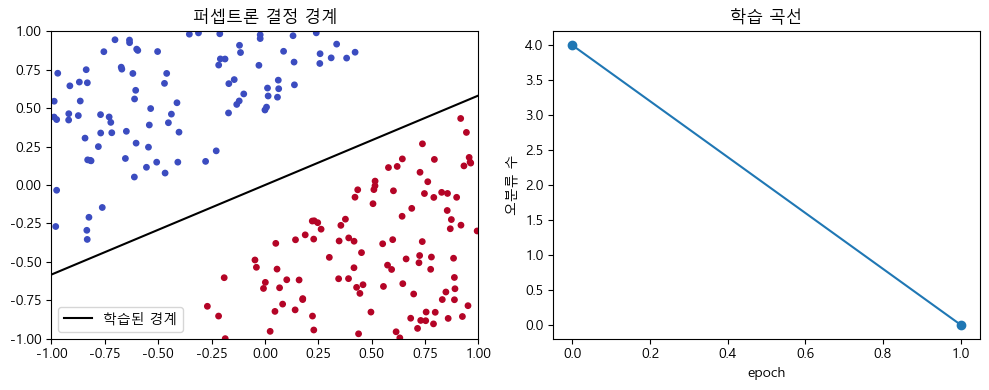

In [2]:
def perceptron_train(X, y, lr=1.0, max_epochs=1000):
    """Rosenblatt 학습 규칙. X: (N,d) (바이어스 열 포함), y: {-1,+1}. 반환: w, 갱신 횟수, 에폭별 오류 수"""
    w = np.zeros(X.shape[1]); n_updates = 0; history = []
    for epoch in range(max_epochs):
        errors = 0
        for xi, yi in zip(X, y):
            # TODO(1): 오분류(또는 경계 위, 즉 y_i * (w·x_i) <= 0)인 샘플에 대해서만
            #          w <- w + lr * y_i * x_i 로 갱신하고 n_updates 와 errors 를 1씩 늘린다.
            #   힌트: 넘파이 내적은 w @ xi. 올바르게 분류된 샘플은 건드리지 않는다.
            if yi * (w @ xi) <= 0:          # 부호가 다르면(오분류) 또는 0이면(경계 위) 갱신 대상
                w += lr * yi * xi            # 정답 레이블 방향으로 w 를 끌어당김
                n_updates += 1; errors += 1
        history.append(errors)
        if errors == 0: break               # 모든 샘플이 올바르게 분류되면 종료
    return w, n_updates, history

def make_separable(n=200, margin=0.5, d=2, seed=0):
    """진짜 분리 초평면 w*로부터 마진 이상 떨어진 점만 남겨 선형 분리 가능 데이터 생성"""
    rng = np.random.default_rng(seed)
    w_star = rng.normal(size=d); w_star /= np.linalg.norm(w_star)
    X = rng.uniform(-1, 1, size=(4*n, d))
    s = X @ w_star
    keep = np.abs(s) >= margin
    X, s = X[keep][:n], s[keep][:n]
    y = np.where(s > 0, 1, -1)
    Xb = np.hstack([np.ones((len(X),1)), X])   # x0 = 1 (바이어스)
    return Xb, y, w_star

Xb, y, w_star = make_separable(margin=0.3)
w, n_upd, hist = perceptron_train(Xb, y)
print(f'갱신 횟수 = {n_upd}, 에폭 수 = {len(hist)}, 최종 훈련 오류 = {hist[-1]}')

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].scatter(Xb[:,1], Xb[:,2], c=y, cmap='coolwarm', s=15)
xs = np.linspace(-1,1,2)
# TODO(2): 학습된 w 로 결정 경계를 그릴 좌표를 계산하라 (변수 이름은 boundary_x2).
#          경계는 w0 + w1*x1 + w2*x2 = 0 이므로 이를 x2 에 대해 풀면 된다.
#   힌트: xs 배열의 각 x1 값에 대응하는 x2 값을 한 번에 계산한다.
boundary_x2 = -(w[0] + w[1] * xs) / w[2]   # w0 + w1*x1 + w2*x2 = 0 → x2 = -(w0 + w1*x1) / w2
ax[0].plot(xs, boundary_x2, 'k-', label='학습된 경계')
ax[0].set_title('퍼셉트론 결정 경계'); ax[0].set_xlim(-1,1); ax[0].set_ylim(-1,1); ax[0].legend()
ax[1].plot(hist, 'o-'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('오분류 수'); ax[1].set_title('학습 곡선')
plt.tight_layout(); plt.show()

### 실험: 마진 $\gamma$가 작아질수록 갱신 횟수가 $(R/\gamma)^2$ 스케일로 증가하는가?

**개념: R 은 "데이터가 얼마나 멀리 퍼져 있나", γ 는 "두 클래스 사이 빈 틈이 얼마나 넓나"**

- Novikoff 상한 (R/γ)² : 틈(γ)이 좁을수록, 데이터가 넓게 퍼질수록(R) 갱신이 더 많이 필요하다.
- 여기서 x = [1, x1, x2] 이고 x1, x2 ∈ [-1, 1] 이므로 ||x|| ≤ √(1² + 1² + 1²) = √3. **바이어스 성분 1 도 벡터의 일부**라서 빼면 안 된다.
- γ 가 절반이 되면 상한은 2² = 4 배가 된다. 로그-로그 그래프에서는 기울기 -2 인 직선으로 보인다.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


  margin      평균 갱신횟수     (R/γ)^2 상한
   0.400          3.4           18.7
   0.200          4.8           75.0
   0.100          7.6          300.0
   0.050          8.0         1200.0
   0.025         12.4         4800.0


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


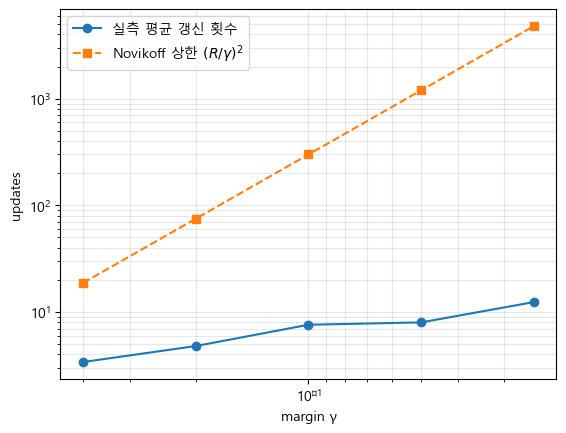

In [3]:
margins = [0.4, 0.2, 0.1, 0.05, 0.025]
rows = []
for g in margins:
    ups = []
    for seed in range(10):
        Xb, y, _ = make_separable(margin=g, seed=seed)
        _, n_upd, _ = perceptron_train(Xb, y, max_epochs=5000)
        ups.append(n_upd)
    # TODO(3): 데이터 반지름 R(= ||x||의 상한)과 Novikoff 상한 (R/γ)^2 을 계산해
    #          rows 에 (γ, 평균 갱신 횟수, 상한) 튜플을 추가하라.
    #   힌트: 바이어스 x0=1 이고 x1,x2 ∈ [-1,1] 이므로 ||x|| ≤ sqrt(1+1+1) 이다.
    R = np.sqrt(3.0)                            # 바이어스 성분 x0=1 까지 포함 → sqrt(1+1+1) (sqrt(2) 아님)
    rows.append((g, np.mean(ups), (R / g) ** 2))  # 시드 10개의 '평균' 갱신 횟수와 상한
print(f"{'margin':>8} {'평균 갱신횟수':>12} {'(R/γ)^2 상한':>14}")
for g, m, b in rows: print(f'{g:8.3f} {m:12.1f} {b:14.1f}')

plt.loglog([r[0] for r in rows], [r[1] for r in rows], 'o-', label='실측 평균 갱신 횟수')
plt.loglog([r[0] for r in rows], [r[2] for r in rows], 's--', label='Novikoff 상한 $(R/\\gamma)^2$')
plt.gca().invert_xaxis(); plt.xlabel('margin γ'); plt.ylabel('updates'); plt.legend(); plt.grid(True, which='both', alpha=.3)
plt.show()

**해석.** 실측 갱신 횟수는 항상 상한 아래에 있으며, 마진이 절반이 되면 대략 4배 가까이 증가하는 $1/\gamma^2$ 경향을 보입니다. 상한은 *최악의 샘플 순서*에 대한 것이므로 실측치는 보통 훨씬 작습니다.

> **심화 (대학원):** 퍼셉트론은 분리 초평면을 *아무거나* 찾지만, 로지스틱 손실로 경사 하강을 무한히 돌리면 $\mathbf{w}/\|\mathbf{w}\|$ 가 **최대 마진(hard-margin SVM) 방향으로 수렴**합니다 (Soudry et al., JMLR 2018, "implicit bias"). 최근 연구는 다중 클래스(NeurIPS 2024)와 Muon·스펙트럴 디센트(2025, 스펙트럴 노름 기준 최대 마진)로 확장되었습니다. 강의 슬라이드 참고.


## 파트 2. 논리 게이트와 선형 분리 가능성

입력 $(x_1,x_2)\in\{0,1\}^2$ 에 대해 AND, OR, XOR 을 퍼셉트론으로 학습시켜 봅니다. 활성화 함수는 계단 함수이며 출력은 $\{0,1\}$ 로 표현합니다.


**개념: 출력 표현은 {0,1}, 학습 레이블은 {-1,+1} 로 구분해야 한다**

- 진리표는 0/1 이지만 퍼셉트론 학습 규칙은 y ∈ {-1, +1} 을 가정한다. y = 0 이면 y_i · (w · x_i) 가 항상 0 이 되어 "늘 틀림" 상태가 되고, 갱신량 η · 0 · x_i 도 0 이라 아무것도 배우지 못한다.
- 예측할 때는 반대로 계단 함수 (w · x > 0 이면 1, 아니면 0) 로 다시 0/1 을 만든다.
- XOR 은 (0,1),(1,0) 이 1 이고 (0,0),(1,1) 이 0 이다. 대각선끼리 같은 클래스라서 **직선 하나로는 절대 나눌 수 없다.** 따라서 XOR 정확도가 1.00 이 나오면 구현이 틀린 것이다.

AND: w = [-4.  3.  2.], 갱신 18회, 훈련 정확도 = 1.00
OR: w = [-1.  2.  2.], 갱신 9회, 훈련 정확도 = 1.00
XOR: w = [0. 0. 0.], 갱신 400회, 훈련 정확도 = 0.50


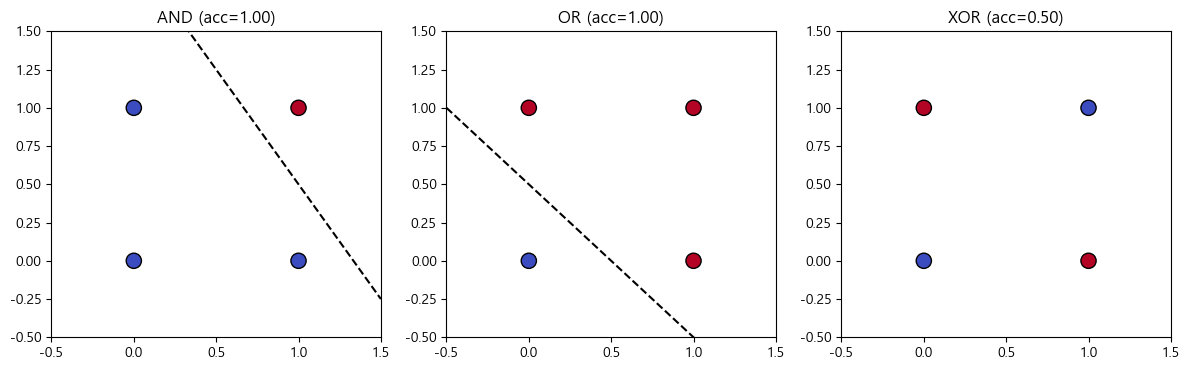

In [4]:
X_gate = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
Xb_gate = np.hstack([np.ones((4,1)), X_gate])
gates = {'AND': np.array([0,0,0,1]), 'OR': np.array([0,1,1,1]), 'XOR': np.array([0,1,1,0])}

fig, axes = plt.subplots(1, 3, figsize=(12,3.8))
for ax, (name, t) in zip(axes, gates.items()):
    # TODO(4): 진리표 t (0/1) 를 퍼셉트론 레이블 y_pm ∈ {-1,+1} 로 바꾸고,
    #          perceptron_train(Xb_gate, y_pm, max_epochs=100) 으로 학습해 w, n_upd, hist 를 얻어라.
    #   힌트: np.where 로 0 → -1, 1 → +1.
    y_pm = np.where(t == 1, 1, -1)   # 0 을 그대로 쓰면 yi*(w@xi) 가 항상 0 이 되어 학습이 망가짐
    w, n_upd, hist = perceptron_train(Xb_gate, y_pm, max_epochs=100)
    # TODO(5): 학습된 w 로 네 입력의 게이트 출력을 0/1 로 예측해 pred 에 담아라.
    #   힌트: 계단 함수이므로 (Xb_gate @ w > 0) 을 정수형으로 바꾼다.
    pred = (Xb_gate @ w > 0).astype(int)   # 계단 함수: z > 0 이면 1, 아니면 0 (바이어스 열 포함한 Xb_gate 사용)
    print(f'{name}: w = {np.round(w,2)}, 갱신 {n_upd}회, 훈련 정확도 = {np.mean(pred==t):.2f}')
    ax.scatter(X_gate[:,0], X_gate[:,1], c=t, cmap='coolwarm', s=120, edgecolor='k')
    if abs(w[2]) > 1e-9:
        xs = np.linspace(-.5,1.5,2); ax.plot(xs, -(w[0]+w[1]*xs)/w[2], 'k--')
    ax.set_title(f'{name} (acc={np.mean(pred==t):.2f})'); ax.set_xlim(-.5,1.5); ax.set_ylim(-.5,1.5)
plt.tight_layout(); plt.show()

**결과.** AND/OR 은 몇 번의 갱신으로 수렴하지만 XOR 은 `max_epochs` 를 다 써도 정확도가 0.5~0.75 를 넘지 못합니다. 이는 알고리즘의 문제가 아니라 **표현력의 한계**입니다 (Minsky & Papert, 1969) — 단일 초평면으로는 XOR 의 두 클래스를 나눌 수 없습니다. 해결책은 파트 4에서 다룹니다.


## 파트 3. scikit-learn `Perceptron` — 필기체 숫자 분류 (기존 실습 갱신)

sklearn 의 `Perceptron` 은 다중 클래스에 대해 자동으로 one-vs-rest 를 수행합니다. 기존 실습 코드를 최신 API 관례(`ConfusionMatrixDisplay`, `StandardScaler` 파이프라인)로 정리했습니다.


**개념: 표준화(StandardScaler)와 one-vs-rest**

- 픽셀값은 0~16 이고 가장자리 픽셀은 거의 항상 0 이다. 특징마다 평균 0, 표준편차 1 로 맞추면 특정 픽셀이 갱신을 독점하지 않아 학습이 안정적이다.
- `make_pipeline` 으로 묶으면 `fit` 할 때 **훈련 데이터로만** 평균/표준편차를 구한다. 테스트 데이터에는 그 값을 그대로 적용하므로 정보 누수가 없다.
- 클래스가 10개이므로 퍼셉트론도 10개(숫자 k vs 나머지)를 따로 학습한다. 예측은 점수가 가장 큰 클래스로 한다. 그래서 `coef_` 의 shape 이 (10, 64) 다.

테스트 정확도 = 0.94
              precision    recall  f1-score   support

           0      0.957     0.978     0.967        45
           1      0.911     0.891     0.901        46
           2      0.977     0.977     0.977        44
           3      0.938     0.978     0.957        46
           4      0.977     0.933     0.955        45
           5      0.898     0.957     0.926        46
           6      0.936     0.978     0.957        45
           7      0.977     0.933     0.955        45
           8      0.878     0.837     0.857        43
           9      0.955     0.933     0.944        45

    accuracy                          0.940       450
   macro avg      0.940     0.940     0.940       450
weighted avg      0.940     0.940     0.940       450



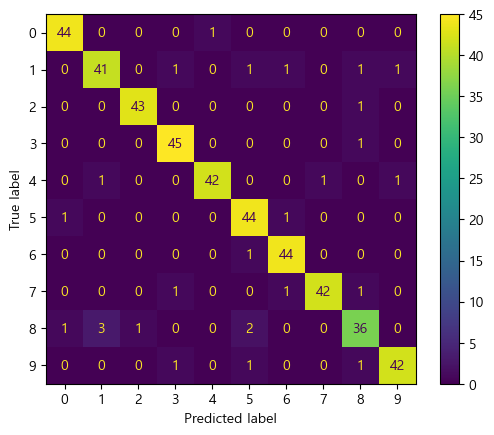

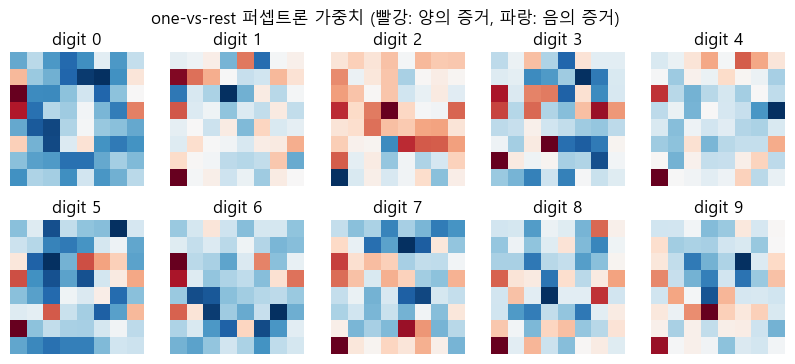

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1, stratify=y)

# TODO(6): 표준화(StandardScaler) → Perceptron(tol=1e-3, random_state=0) 파이프라인 clf 를 만들고
# 훈련 데이터로 학습한 뒤, 테스트셋 예측을 y_pred 에 담아라.
# 힌트: make_pipeline 을 쓰면 clf[-1] 로 마지막 단계(퍼셉트론)에 접근할 수 있다.
# 다중 클래스는 sklearn 이 자동으로 one-vs-rest 로 처리한다.
clf = make_pipeline(StandardScaler(), Perceptron(tol=1e-3, random_state=0))
clf.fit(X_train, y_train)      # 스케일러의 평균/표준편차는 훈련 데이터로만 계산됨 (테스트 정보 누수 방지)
y_pred = clf.predict(X_test)
print('테스트 정확도 =', round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred); plt.show()

# 가중치 벡터를 8x8 이미지로 시각화: 각 클래스 퍼셉트론이 "어떤 픽셀"에 반응하는지
W = clf[-1].coef_
fig, axes = plt.subplots(2,5, figsize=(10,4))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(W[k].reshape(8,8), cmap='RdBu'); ax.set_title(f'digit {k}'); ax.axis('off')
plt.suptitle('one-vs-rest 퍼셉트론 가중치 (빨강: 양의 증거, 파랑: 음의 증거)'); plt.show()

## 파트 4. PyTorch — 퍼셉트론(로지스틱 회귀)과 2층 MLP

* **활성화를 시그모이드로 바꾼 퍼셉트론 = 로지스틱 회귀** 입니다. `nn.Linear(2,1)` + `BCEWithLogitsLoss` 로 구현하면 손실이 볼록(convex)이라 경사 하강이 전역 최적에 도달합니다.
* **은닉층 하나를 추가한 2층 MLP** 는 XOR 을 풀 수 있습니다 (은닉 뉴런 2개면 충분).
* 최신 관례: `torch.optim.AdamW`, `torch.nn.functional`, 명시적 시드, 배치 전체를 텐서로 처리.


**개념: PyTorch 학습 한 스텝 = 순전파 → 손실 → zero_grad → backward → step**

| 단계 | 하는 일 |
|---|---|
| `logits = model(X)` | 순전파. 시그모이드를 통과하기 **전** 점수(logit) |
| `F.binary_cross_entropy_with_logits` | 내부에서 시그모이드 + BCE 를 함께 계산한다. 따로 계산하면 log(0) 이 생길 수 있어 이 함수가 더 안정적이다 |
| `opt.zero_grad()` | PyTorch 는 기울기를 **누적**하므로 매 스텝 0 으로 비워야 한다 |
| `loss.backward()` | 역전파: 모든 파라미터의 ∂L/∂θ 계산 |
| `opt.step()` | AdamW 로 가중치 갱신 |

- `nn.Linear(2,1)` + 시그모이드는 **로지스틱 회귀**이고 결정 경계는 여전히 직선 하나다. 그래서 XOR 에서는 loss 가 log 2 ≈ 0.693 근처에 머문다. 이 값은 "모든 점에 확률 0.5" 라는 뜻이다.
- 은닉층(tanh)을 하나 넣으면 경계가 휘어질 수 있다.

In [ ]:
import torch.nn as nn, torch.nn.functional as F

Xt = torch.tensor(X_gate, dtype=torch.float32)
yt_xor = torch.tensor(gates['XOR'], dtype=torch.float32).unsqueeze(1)

def train_torch(model, X, y, epochs=2000, lr=0.1, wd=0.0, log_every=500):
    """AdamW 로 이진 분류 모델을 학습한다. 반환: 학습이 끝난 model"""
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    for ep in range(1, epochs+1):
        # TODO(7): 학습 한 스텝을 구현하라 — 순전파로 logits 를 얻고,
        # BCEWithLogits 손실 loss 를 계산한 뒤, zero_grad → backward → step 순서로 갱신한다.
        # 힌트: F.binary_cross_entropy_with_logits(logits, y)
        logits = model(X) # 순전파 (시그모이드 통과 전 값)
        loss = F.binary_cross_entropy_with_logits(logits, y) # 시그모이드 + BCE 를 한 번에 
        opt.zero_grad() # 이전 스텝의 기울기 초기화
        loss.backward() # 역전파로 각 파라미터의 기울기 계산
        opt.step() # 기울기 방향으로 가중치 갱신
        if ep % log_every == 0 or ep == 1:
            acc = ((logits > 0).float() == y).float().mean().item()
            print(f'  epoch {ep:5d}  loss={loss.item():.4f}  acc={acc:.2f}')
    return model

torch.manual_seed(0)
print('[1] 단층 퍼셉트론 (nn.Linear 2→1) on XOR')
single = nn.Linear(2, 1)
train_torch(single, Xt, yt_xor)

torch.manual_seed(0)
print('\n[2] 2층 MLP (2→2→1, tanh) on XOR')
# TODO(8): 은닉 뉴런 2개와 tanh 활성화를 쓰는 2층 MLP (2→2→1) 를 nn.Sequential 로 정의해 mlp 에 담아라.
# 힌트: Linear → Tanh → Linear. 은닉 2개면 XOR 을 풀기에 충분하다.
mlp = nn.Sequential(nn.Linear(2, 2), nn.Tanh(), nn.Linear(2, 1))   # 입력 2 → 은닉 2 (tanh) → 출력 1 (logit)
train_torch(mlp, Xt, yt_xor)

[1] 단층 퍼셉트론 (nn.Linear 2→1) on XOR
  epoch     1  loss=0.7168  acc=0.50
  epoch   500  loss=0.6931  acc=0.50
  epoch  1000  loss=0.6931  acc=0.50
  epoch  1500  loss=0.6931  acc=0.50
  epoch  2000  loss=0.6931  acc=0.50

[2] 2층 MLP (2→2→1, tanh) on XOR
  epoch     1  loss=0.7152  acc=0.25
  epoch   500  loss=0.0009  acc=1.00
  epoch  1000  loss=0.0003  acc=1.00
  epoch  1500  loss=0.0001  acc=1.00
  epoch  2000  loss=0.0001  acc=1.00


Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): Tanh()
  (2): Linear(in_features=2, out_features=1, bias=True)
)

### 결정 경계와 은닉 특징 공간 시각화 — TODO(9), TODO(10)

위에서 학습한 두 모델의 결정 경계를 그리고, 은닉층이 XOR 을 선형 분리 가능하게 재배치하는지 확인한다.

**개념: 은닉층은 <XOR 을 풀 수 있는 새 좌표계로 옮겨 주는 변환>임

- 원래 입력 공간에서는 XOR 을 직선으로 나눌 수 없다. 하지만 은닉층 출력 h = tanh(W1 · x + b1) 공간으로 옮기면 두 클래스가 직선 하나로 나뉘는 위치로 재배치된다.
- 출력층은 그 h 공간에서 그냥 **퍼셉트론 하나**다. <특징 학습(은닉층) + 선형 분류기(출력층)> 구조라는 뜻
- `mlp[0]` 은 `nn.Sequential` 의 첫 번째 층(Linear)이다. 여기에 직접 `torch.tanh` 를 씌우면 `mlp[1]`(Tanh)까지 통과한 값과 같다.

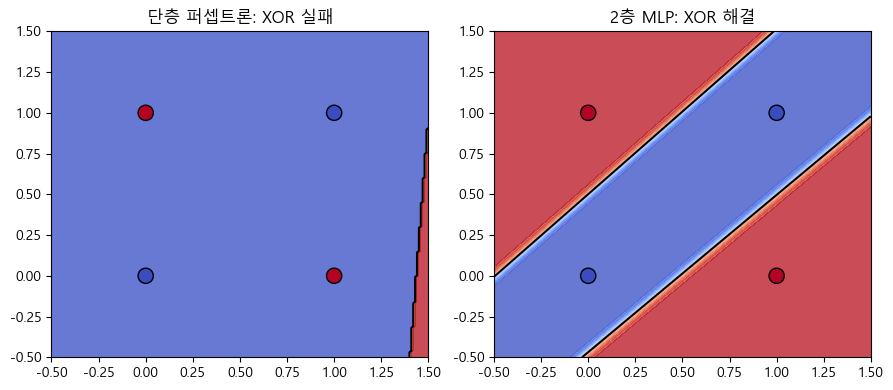

은닉층 출력 h(x):
[[-0.99 -0.98]
 [ 0.99 -1.  ]
 [-1.    0.99]
 [-0.99 -0.99]]


In [ ]:
def plot_boundary(model, title, ax):
    xx, yy = np.meshgrid(np.linspace(-.5,1.5,200), np.linspace(-.5,1.5,200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    # TODO(9): 그리드 전체에 대한 모델의 예측 확률 zz 를 계산하라 (xx 와 같은 모양의 넘파이 배열).
    #   힌트: 기울기가 필요 없으니 with torch.no_grad(): 안에서 torch.sigmoid(model(grid)) 를 구하고
    #         .numpy().reshape(xx.shape) 로 모양을 맞춘다.
    with torch.no_grad():   
        zz = torch.sigmoid(model(grid)).numpy().reshape(xx.shape) 
    ax.contourf(xx, yy, zz, levels=20, cmap='coolwarm', alpha=.8)
    ax.contour(xx, yy, zz, levels=[0.5], colors='k')
    ax.scatter(X_gate[:,0], X_gate[:,1], c=gates['XOR'], cmap='coolwarm', s=120, edgecolor='k')
    ax.set_title(title)

fig, axes = plt.subplots(1,2, figsize=(9,4))
plot_boundary(single, '단층 퍼셉트론: XOR 실패', axes[0])
plot_boundary(mlp, '2층 MLP: XOR 해결', axes[1])
plt.tight_layout(); plt.show()

# 은닉층이 만든 새로운 특징 공간에서는 XOR가 선형 분리 가능해진다
# TODO(10): 네 입력에 대한 은닉층 출력 h(x) = tanh(W1 x + b1) 을 계산해 넘파이 배열 H 에 담아라.
#   힌트: mlp[0] 이 첫 번째 Linear 층이다. with torch.no_grad(): 안에서 계산한다.
with torch.no_grad():
    H = torch.tanh(mlp[0](Xt)).numpy()
print('은닉층 출력 h(x):'); print(np.round(H, 2))

**핵심 메시지.** 은닉층은 입력을 *새로운 좌표계* $\mathbf{h}=\phi(W_1\mathbf{x}+\mathbf{b}_1)$ 로 옮기고, 출력층은 그 공간에서 **다시 퍼셉트론**을 적용합니다. 위 `H` 출력에서 XOR 의 두 클래스가 선형 분리 가능하게 재배치된 것을 확인하세요. 이 "특징 학습 + 선형 분류기" 구조가 CNN·트랜스포머까지 이어지는 딥러닝의 기본 골격입니다.


### 4-b. PyTorch MLP 로 필기체 숫자 분류 — 파트 3의 선형 퍼셉트론과 비교

**개념: 다중 클래스 = softmax + 교차 엔트로피, 평가 때는 `model.eval()`**

- `nn.Linear(64,10)` 은 퍼셉트론 10개를 묶은 것(softmax 회귀). `F.cross_entropy` 는 logit 을 받아 내부에서 softmax 와 음의 로그우도를 함께 계산
- 예측은 `argmax(1)` 로 logit 이 가장 큰 클래스를 고른다. softmax 는 순서를 바꾸지 않으므로 확률로 바꿀 필요가 없다.
- **Dropout 은 학습할 때 뉴런을 무작위로 끈다.** 평가 때도 켜져 있으면 예측이 매번 흔들림. `model.eval()` 로 끄고 정확도를 계산한 뒤 `model.train()` 으로 되돌림
- Droupout이 없는 선형모델은 영향이 없다.
- GELU 는 ReLU 를 부드럽게 만드는 활성화 함수로, GPT·BERT 의 FFN 에서 쓰인다.

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train)
Xtr = torch.tensor(sc.transform(X_train), dtype=torch.float32); ytr = torch.tensor(y_train)
Xte = torch.tensor(sc.transform(X_test),  dtype=torch.float32); yte = torch.tensor(y_test)

def fit_classifier(model, epochs=60, lr=1e-3, bs=64):
    """미니배치 SGD(AdamW)로 다중 클래스 분류기를 학습하고 테스트 정확도(float)를 반환한다."""
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    n = len(Xtr)
    for ep in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            # TODO(11): 미니배치 한 스텝을 구현하라 — 순전파 → 교차 엔트로피 손실 →
            #           zero_grad → backward → step.
            #   힌트: F.cross_entropy(model(Xtr[idx]), ytr[idx])
            loss = F.cross_entropy(model(Xtr[idx]), ytr[idx])   # softmax + 음의 로그우도를 한 번에 계산
            opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        # TODO(12): 테스트셋 정확도를 계산해 파이썬 float 로 반환하라.
        #   힌트: model(Xte).argmax(1) 과 yte 를 비교한 뒤 평균을 내고 .item() 을 쓴다.
        model.eval()  # Dropout 끄기.평가 때는 모든 뉴런을 사용
        acc = (model(Xte).argmax(1) == yte).float().mean().item() 
        model.train() # 다시 학습 모드로 되돌려 둠
        return acc

torch.manual_seed(0)
acc_lin = fit_classifier(nn.Linear(64, 10)) # 다중클래스 퍼셉트론(softmax 회귀)
torch.manual_seed(0)
# TODO(13): 은닉 128 + GELU + Dropout(0.1) 을 쓰는 2층 MLP (64→128→10) 를 정의하고
# fit_classifier 로 학습·평가해 정확도를 acc_mlp 에 담아라.
# 힌트: nn.Sequential(nn.Linear(...), nn.GELU(), nn.Dropout(0.1), nn.Linear(...))
mlp_digits = nn.Sequential(nn.Linear(64, 128), nn.GELU(), nn.Dropout(0.1), nn.Linear(128, 10))
acc_mlp = fit_classifier(mlp_digits)  # 이름을 mlp 로 하면 위의 XOR 모델을 덮어쓰므로 따로 둠
print(f'선형(softmax 퍼셉트론) 테스트 정확도 = {acc_lin:.4f}')
print(f'2층 MLP(GELU)      테스트 정확도 = {acc_mlp:.4f}')

선형(softmax 퍼셉트론) 테스트 정확도 = 0.9600
2층 MLP(GELU)      테스트 정확도 = 0.9667



> **참고 (model.eval())** : 정답 예시처럼 `model.eval()` 없이 평가하면 MLP 정확도가 **0.9711**, 넣으면 **0.9667** 이다(450개 중 2개 차이). 선형 모델은 Dropout 이 없어 0.9600 으로 같다. eval 없이 나온 0.9711 은 Dropout 이 켜진 채 무작위로 뉴런을 끈 상태의 값이라, 실행할 때마다 달라질 수 있다. 그래서 평가는 `model.eval()` 상태에서 하는 것이 맞다.

## 파트 5. 트랜스포머 블록 안의 퍼셉트론

LLM 을 구성하는 트랜스포머 블록은 **어텐션**과 **FFN(feed-forward network)** 의 반복입니다. FFN 은 정확히 우리가 방금 만든 2층 MLP 이며 (`Linear → 활성화 → Linear`), GPT 계열 모델 파라미터의 약 2/3 가 여기에 있습니다. 아래에서 PyTorch 의 `TransformerEncoderLayer` 를 열어 확인합니다.


**개념: FFN 파라미터 직접 세 보기 (d_model=64, dim_feedforward=256)**

| 부분 | 계산 | 개수 |
|---|---|---|
| FFN `linear1` (64→256) | 64×256 + 256 | 16,640 |
| FFN `linear2` (256→64) | 256×64 + 64 | 16,448 |
| 어텐션 `in_proj` (Q,K,V) | 3×64×64 + 3×64 | 12,480 |
| 어텐션 `out_proj` | 64×64 + 64 | 4,160 |
| LayerNorm ×2 | 2×(64+64) | 256 |
| **합계** | | **49,984** |

FFN 은 33,088 / 49,984 ≈ 66.2% 로 약 2/3 를 차지한다. FFN 폭을 4d 로 두면 FFN 이 약 8d², 어텐션이 약 4d² 이 되기 때문이다.
FFN 의 은닉 뉴런 하나하나가 "w1 · x + b → ReLU" 인 퍼셉트론이다.

In [15]:
layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=256, batch_first=True)
print(layer)
# TODO(14): FFN(= linear1 + linear2) 의 파라미터 수 n_ffn 과 이 층 전체 파라미터 수 n_all 을 구하라.
# 힌트: layer.named_parameters() 에서 이름에 'linear' 가 들어간 것만 골라 p.numel() 을 더한다.
n_ffn = sum(p.numel() for n, p in layer.named_parameters() if 'linear' in n)   # linear1, linear2 의 weight + bias
n_all = sum(p.numel() for p in layer.parameters())
print(f'\nFFN(2층 MLP) 파라미터 비율 = {n_ffn/n_all:.1%}')

x = torch.randn(1, 5, 64)                     # (batch, tokens, d_model)
# TODO(15): FFN 의 첫 번째 선형층에 x 를 통과시키고 ReLU 를 적용한 h 를 구하라.
# (256개의 "퍼셉트론"이 각 토큰에 대해 발화 여부를 결정한다)
# 힌트: layer.linear1 과 F.relu 를 쓴다.
h = F.relu(layer.linear1(x)) 
print('활성화된 FFN 뉴런 비율(토큰별):', (h > 0).float().mean(dim=-1).squeeze().numpy().round(2))

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (linear1): Linear(in_features=64, out_features=256, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=256, out_features=64, bias=True)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

FFN(2층 MLP) 파라미터 비율 = 66.2%
활성화된 FFN 뉴런 비율(토큰별): [0.47 0.51 0.44 0.53 0.51]


**정리.**
1. 퍼셉트론 = 가중합 + 비선형 활성화. 학습 규칙은 오분류 샘플에 대한 SGD 이고, 분리 가능하면 $(R/\gamma)^2$ 회 이내에 수렴한다.
2. 단일 퍼셉트론은 선형 분리 가능한 문제(AND, OR)만 풀 수 있고 XOR 은 못 푼다.
3. 은닉층을 쌓으면(MLP) 표현력이 보편 근사(universal approximation)로 확장되고, 학습은 역전파로 한다.
4. 트랜스포머·LLM 의 FFN 은 2층 MLP 이며, 어텐션도 "학습된 가중합"이라는 점에서 퍼셉트론의 직계 후손이다.

**과제(선택).** (a) 파트 1에서 학습률 $\eta$ 를 바꿔도 갱신 횟수가 변하지 않는 이유를 수식으로 설명하시오. (b) 파트 4의 MLP 에 은닉 뉴런을 1개만 두면 XOR 을 풀 수 있는지 실험하고 이유를 설명하시오. (c) 파트 4-b 에서 은닉층 폭을 32, 128, 512 로 바꿔 정확도와 파라미터 수를 표로 정리하시오.


---
# 과제(선택) 답변

## (a) 학습률 η 를 바꿔도 갱신 횟수가 변하지 않는 이유

In [ ]:
# (a) 같은 데이터에 η 만 바꿔 학습하는 실험 진행
Xb_a, y_a, _ = make_separable(margin=0.1, seed=0)
w_ref = None
for lr in [0.01, 0.1, 1.0, 10.0, 100.0]:
    w_a, n_a, h_a = perceptron_train(Xb_a, y_a, lr=lr, max_epochs=5000)
    w_dir = w_a / lr # η 로 나누면 모두 같은 벡터가 나와야 함
    if w_ref is None: w_ref = w_dir
    print(f'lr={lr:7.2f}  갱신 횟수={n_a:4d}  에폭 수={len(h_a):3d}  '
          f'w/lr={np.round(w_dir, 3)}  (lr=0.01 과 같은가? {np.allclose(w_dir, w_ref)})')

lr=   0.01  갱신 횟수=  16  에폭 수=  4  w/lr=[ 0.     3.151 -3.307]  (lr=0.01 과 같은가? True)
lr=   0.10  갱신 횟수=  16  에폭 수=  4  w/lr=[ 0.     3.151 -3.307]  (lr=0.01 과 같은가? True)
lr=   1.00  갱신 횟수=  16  에폭 수=  4  w/lr=[ 0.     3.151 -3.307]  (lr=0.01 과 같은가? True)
lr=  10.00  갱신 횟수=  16  에폭 수=  4  w/lr=[ 0.     3.151 -3.307]  (lr=0.01 과 같은가? True)
lr= 100.00  갱신 횟수=  16  에폭 수=  4  w/lr=[ 0.     3.151 -3.307]  (lr=0.01 과 같은가? True)


**답 (a)**

학습률 η 를 0.01 부터 100 까지 10⁴ 배 바꿔 가며 같은 데이터로 학습해 보았다. 다섯 경우 모두 갱신 횟수는 16회, 에폭 수는 4회로 똑같았다. 최종 가중치를 η 로 나눈 값도 `[0, 3.151, -3.307]` 로 완전히 같았다. 즉 η 는 학습 과정을 바꾸지 못하고 가중치의 크기만 키웠다.

이렇게 되는 이유는 가중치를 0 벡터에서 시작하기 때문이다. 퍼셉트론은 틀린 샘플을 만날 때마다 η · y_i · x_i 를 더한다. 그래서 몇 번 갱신하든 가중치는 "지금까지 틀린 샘플들의 y_i · x_i 를 모두 더한 벡터"에 η 를 곱한 꼴, 즉 w = η · v 가 된다. 여기서 v 는 η 와는 관계가 없다.

오분류 판정 y_i · (w · x_i) ≤ 0 을 보면, 이 값은 η · y_i · (v · x_i) 와 같다. η 는 항상 양수이므로 곱해도 부호가 바뀌지 않는다. 따라서 어떤 샘플이 틀렸는지에 대한 판단은 η 가 얼마든 똑같다. 첫 번째 갱신이 같은 샘플에서 일어나면 그다음 v 도 같아지고, 그다음 판정도 같아진다. 이것이 끝까지 이어지므로 갱신이 일어나는 순서와 횟수가 모두 같다. 결국 η 는 가중치 벡터의 길이만 바꾸고 방향은 바꾸지 않는다. 결정 경계 w · x = 0 은 벡터의 방향으로만 정해지므로 경계도 그대로다.

다만 이 성질은 가중치를 0 으로 초기화했을 때만 성립한다. 무작위 값으로 초기화하면 가중치가 '초기값 + η · v' 가 되어, η 가 크냐 작냐에 따라 초기값이 차지하는 비중이 달라진다. 그러면 오분류 판정도 달라지고 갱신 횟수도 η 에 따라 변하게 된다.

## (b) 은닉 뉴런이 1개뿐인 MLP 로 XOR 을 풀 수 있는가?

은닉 뉴런 1개(2→1→1)와 2개(2→2→1)를 시드 10개로 학습해 비교한다. 학습 설정은 파트 4 와 같다(AdamW, lr=0.1, 2000 에폭).

  은닉 수 | 시드별 정확도 (0~9)                                        | 최고 정확도 | 1.00 달성 시드 수
     1 | 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75    |    0.75    |   0 / 10
     2 | 1.00 0.75 1.00 1.00 1.00 0.50 0.50 0.75 0.50 0.50    |    1.00    |   4 / 10

은닉 1개 모델의 최종 loss (시드별): [0.477 0.477 0.477 0.477 0.477 0.477 0.477 0.477 0.477 0.477]


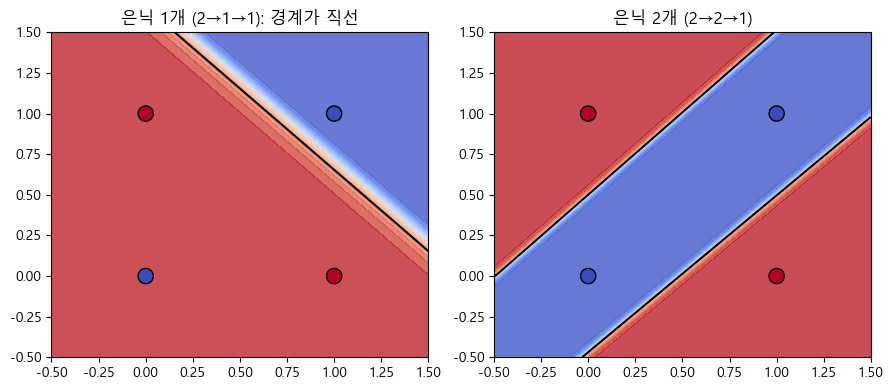

In [ ]:
# (b) : 은닉 뉴런 1개 vs 2개 
def train_quiet(model, X, y, epochs=2000, lr=0.1):
    # train_torch 와 같은 학습을 로그 출력 없이 수행하고 (최종 loss, 정확도) 를 반환
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    for _ in range(epochs):
        logits = model(X)
        loss = F.binary_cross_entropy_with_logits(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        logits = model(X)
        return (F.binary_cross_entropy_with_logits(logits, y).item(),
                ((logits > 0).float() == y).float().mean().item())

res_b = {1: [], 2: []}
models_b = {}
for hidden in [1, 2]:
    for seed in range(10):
        torch.manual_seed(seed)
        m = nn.Sequential(nn.Linear(2, hidden), nn.Tanh(), nn.Linear(hidden, 1))
        res_b[hidden].append(train_quiet(m, Xt, yt_xor))
        if seed == 0: models_b[hidden] = m

print(f"{'은닉 수':>6} | {'시드별 정확도 (0~9)':<52} | 최고 정확도 | 1.00 달성 시드 수")
for hidden in [1, 2]:
    accs = [a for _, a in res_b[hidden]]
    print(f'{hidden:>6} | {" ".join(f"{a:.2f}" for a in accs):<52} | {max(accs):^10.2f} | {sum(a == 1.0 for a in accs):>3d} / 10')
print('\n은닉 1개 모델의 최종 loss (시드별):', np.round([l for l, _ in res_b[1]], 3))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_boundary(models_b[1], '은닉 1개 (2→1→1): 경계가 직선', axes[0])
plot_boundary(models_b[2], '은닉 2개 (2→2→1)', axes[1])
plt.tight_layout(); plt.show()

**답 (b) : 은닉 뉴런 1개로는 XOR 을 풀 수 없다.**

- 은닉 1개 : 시드 10개 **모두 정확도 0.75**, 최종 loss 도 모두 **0.477** 로 같았다. 1.00 은 한 번도 나오지 않았다.
- 은닉 2개 : 시드 10개 중 **4개만** 1.00 이었다. 나머지는 0.50~0.75 에서 멈췄다.
- 왼쪽 그림처럼 은닉 1개 모델의 결정 경계는 **직선 하나**다.

은닉 뉴런이 1개면 은닉 출력은 h = tanh(s), s = w · x + b 인 **스칼라 하나**다. 출력 logit 은 a · h + c = a · tanh(s) + c 다. tanh 는 단조 증가 함수이므로, 출력이 양수인 조건 a · tanh(s) + c > 0 은 결국 **s > t 또는 s < t** (t 는 어떤 임계값) 꼴이 된다. 즉, 결정 경계는 w · x + b = t 라는 직선 하나다. 비선형 활성화를 넣어도 단층 퍼셉트론과 표현력이 같고, 직선으로는 XOR 의 4점 중 최대 3점만 맞힐 수 있다 (0.75).

**loss 가 항상 0.477 인 이유**는 모델이 할 수 있는 최선이 4점 중 1점을 직선으로 떼어 내 확실히 맞히고(loss→0), 나머지 3점(정답 1이 2개, 0이 1개)에는 같은 확률 p 를 주는 것이기 때문이다. 
이때 p = 2/3 가 최적이고 loss = ( -2 · ln(2/3) - ln(1/3) ) / 4 = (0.811 + 1.099) / 4 ≈ 0.477
로 실측값과 정확히 일치한다. 시드와 관계없이 같은 값이 나온 것은 이것이 은닉 1개 모델의 **전역 최적**이기 때문이다.

## (c) 파트 4-b 의 은닉층 폭을 32, 128, 512 로 바꿨을 때

파트 4-b 와 같은 설정(GELU + Dropout(0.1), AdamW lr=1e-3, 60 에폭)에서 은닉 폭만 바꾼다. 시드 하나만 쓰면 우연의 영향이 크므로 **시드 3개(0, 1, 2)의 평균**도 함께 구한다. 비교 기준으로 선형 모델(은닉층 없음)도 넣었다.

모델                         파라미터 수    정확도(seed 0)   평균(3 seeds)     표준편차
선형 (64→10)                    650         0.9600        0.9593   0.0010
MLP 64→32→10                2,410         0.9733        0.9733   0.0018
MLP 64→128→10               9,610         0.9667        0.9704   0.0038
MLP 64→512→10              38,410         0.9756        0.9748   0.0010


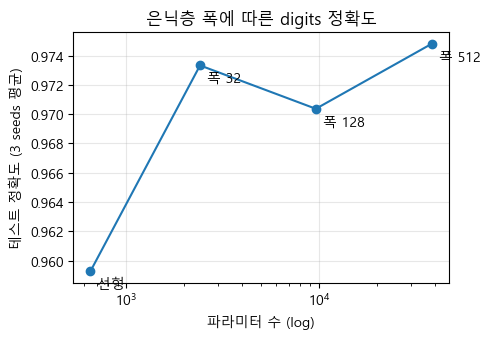

In [ ]:
#(c) : 은닉층 폭에 따른 정확도와 파라미터 수
def make_model(width):
    if width == 0:
        return nn.Linear(64, 10) # 은닉층 없는 선형 모델 
    return nn.Sequential(nn.Linear(64, width), nn.GELU(), nn.Dropout(0.1), nn.Linear(width, 10))

rows_c = []
for width in [0, 32, 128, 512]:
    accs = []
    for seed in [0, 1, 2]:
        torch.manual_seed(seed)
        m = make_model(width)
        accs.append(fit_classifier(m))
    n_params = sum(p.numel() for p in m.parameters())
    rows_c.append((width, n_params, accs[0], np.mean(accs), np.std(accs)))

print(f"{'모델':<22} {'파라미터 수':>10} {'정확도(seed 0)':>14} {'평균(3 seeds)':>13} {'표준편차':>8}")
for width, n_params, a0, am, asd in rows_c:
    name = '선형 (64→10)' if width == 0 else f'MLP 64→{width}→10'
    print(f'{name:<22} {n_params:>10,d} {a0:>14.4f} {am:>13.4f} {asd:>8.4f}')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.semilogx([r[1] for r in rows_c], [r[3] for r in rows_c], 'o-')
for width, n_params, _, am, _ in rows_c:
    ax.annotate('선형' if width == 0 else f'폭 {width}', (n_params, am), textcoords='offset points', xytext=(5, -12))
ax.set_xlabel('파라미터 수 (log)'); ax.set_ylabel('테스트 정확도 (3 seeds 평균)'); ax.grid(True, alpha=.3)
ax.set_title('은닉층 폭에 따른 digits 정확도'); plt.tight_layout(); plt.show()

**(c)**
1. **은닉층을 넣는 것 자체의 효과가 가장 크다.** 선형 0.959 → MLP 0.970~0.975 로 약 1~1.5%p 올랐다. 테스트 450개 기준 5~7개를 더 맞힌 것이다.
2. **폭을 늘리는 효과는 작다.** 폭 32 → 512 로 파라미터가 16배(2410 → 38410) 늘었지만 평균 정확도는 0.9733 → 0.9748 로 0.15%p, 450개 중 1개도 안 되는 차이다. 폭 128 은 오히려 32 보다 낮았다. 테스트 1개가 0.0022 이고 시드 간 표준편차가 0.001~0.004 이므로, MLP 세 개 사이의 순위는 우연 범위 안이다.
3. digits 는 선형 모델로도 96% 가 나올 만큼 거의 선형 분리가 가능한 쉬운 데이터다. 그래서 작은 은닉층(32)만으로도 남은 오류를 대부분 잡을 수 있다.
4. 폭 512 는 파라미터(38410)가 훈련 샘플 수(1347)보다 훨씬 많은데도 성능이 떨어지지 않았다. Dropout(0.1)과 weight decay(1e-4), 그리고 60 에폭이라는 짧은 학습이 과적합을 막았기 때문이다.

→ 이 데이터에서는 **폭 32 가 파라미터 대비 효율이 가장 좋다.**